# Teil 1 - Use Case Analyse

## 1. Datensatz-Beschreibung: Was wurde erfasst, von wem und warum?

Laut der offiziellen Beschreibung auf Kaggle ("E-Commerce Shipping Data", [kaggle.com/datasets/prachi13/customer-analytics](https://www.kaggle.com/datasets/prachi13/customer-analytics)) stammt der Datensatz von einem **internationalen E-Commerce-Unternehmen, das Elektronikprodukte verkauft**. Das Unternehmen wollte anhand seiner Kundendatenbank wichtige Erkenntnisse ("key insights") über sein Geschäft gewinnen, insbesondere im Zusammenhang mit der Lieferzuverlässigkeit.

Der Datensatz enthält **10.999 Bestelldatensätze** (Train.csv, 12 Spalten). Erfasst wurden pro Bestellung u. a.:

- **Logistik-Merkmale**: Lagerblock (`Warehouse_block`: A–F), Versandart (`Mode_of_Shipment`: Flight, Ship, Road), Produktgewicht (`Weight_in_gms`)
- **Kundenbezogene Merkmale**: Anzahl Anrufe beim Kundenservice zur Sendungsanfrage (`Customer_care_calls`), Kundenbewertung 1–5 (`Customer_rating`), Geschlecht (`Gender`), Anzahl früherer Käufe (`Prior_purchases`)
- **Produkt-/Bestellmerkmale**: Produktpreis in USD (`Cost_of_the_Product`), Produktwichtigkeit (`Product_importance`: low/medium/high), gewährter Rabatt (`Discount_offered`)
- **Zielgröße**: ob die Lieferung pünktlich ankam (`Reached.on.Time_Y.N`, 1 = nicht pünktlich, 0 = pünktlich)

Erfasst wurde der Datensatz vom **operativen/logistischen System des Händlers** (Auftragsverwaltung, Versand- und CRM-Systeme), das bei jeder Bestellung automatisch Versand-, Produkt- und Kundendaten mitschreibt. Der Zweck der Erfassung ist die **Nachverfolgung der Lieferzuverlässigkeit**: Das Unternehmen möchte verstehen, welche Faktoren (Versandart, Gewicht, Rabatt, Kundenverhalten etc.) mit verspäteten Lieferungen zusammenhängen, um daraus Optimierungspotenzial für die Lieferkette abzuleiten.

## 2. Business-Fragestellung

**Kann das Unternehmen anhand von Bestell-, Versand- und Kundenmerkmalen einer neuen Sendung frühzeitig erkennen, ob diese sich verspäten wird, um durch gezieltes Gegensteuern (z. B. Versandart wechseln, Kunden proaktiv informieren) Reklamationen zu vermeiden und die Kundenzufriedenheit zu erhöhen?**

## 3. Art des Problems

Es handelt sich um ein **Klassifikationsproblem**, genauer eine **binäre Klassifikation**.

**Begründung:** Die Zielvariable `Reached.on.Time_Y.N` nimmt nur zwei diskrete Werte an (0 = pünktlich, 1 = nicht pünktlich). Es soll also keine kontinuierliche Zahl vorhergesagt werden, sondern eine Bestellung einer von zwei Klassen zugeordnet werden. 

## 4. Mehrwert

Ein trainiertes Modell könnte einem Unternehmen folgenden Nutzen bringen:

- **Proaktives Risikomanagement**: Bestellungen mit hohem Verspätungsrisiko können frühzeitig identifiziert werden, sodass der Kunde informiert oder die Sendung priorisiert bearbeitet werden kann.
- **Optimierung der Lieferkette**: Erkenntnisse darüber, welche Faktoren (z. B. Versandart, Gewicht, Lagerblock) Verspätungen begünstigen, helfen bei der Prozessverbesserung (z. B. Wechsel der Versandart für kritische Produkte).
- **Realistischere Lieferzeitangaben**: Realistischere Lieferzeitangaben erhöhen die Kundenzufriedenheit und senken Support-Anfragen (die Anzahl der `Customer_care_calls` zeigt, dass Lieferunsicherheit bereits heute Supportaufwand verursacht).
- **Kosteneinsparung**: Weniger Reklamationen, Rückerstattungen und Eilzustellungen durch gezieltes Gegensteuern bei Risikobestellungen.
- **Datengetriebene Entscheidungen**: Das Modell liefert eine quantitative Grundlage für strategische Entscheidungen (z. B. Auswahl von Logistikpartnern oder Warehouse-Standorten).

## 5. Einschränkungen

- **Datenqualität und Repräsentativität**: Der Datensatz stammt von einem bestimmten Händler und Zeitraum; das Modell könnte auf andere Märkte, Saisons (z. B. Weihnachtsgeschäft) oder Unternehmen schlecht übertragbar sein.
- **Fehlende Kontextvariablen**: Externe Einflüsse wie Wetter, Zoll, Streiks oder regionale Infrastruktur werden nicht erfasst, obwohl sie Lieferverspätungen stark beeinflussen können.
- **Fairness/Bias**: Merkmale wie `Gender` sollten kritisch geprüft werden, damit das Modell keine unfairen oder diskriminierenden Muster lernt (z. B. unterschiedliche Behandlung von Kundengruppen ohne sachlichen Grund).
- **Fehlinterpretation von Korrelation als Kausalität**: Ein Zusammenhang zwischen einem Merkmal (z. B. Rabatt) und Verspätung bedeutet nicht zwangsläufig eine ursächliche Beziehung.
- **Fehlklassifikationen und Konsequenzen**: Falsch-negative Vorhersagen (angeblich pünktlich, tatsächlich verspätet) könnten dazu führen, dass Kunden nicht rechtzeitig informiert werden; die Kosten von Fehlern in beide Richtungen sollten bei der Modellbewertung berücksichtigt werden.

# Teil 2 - Datenprozessierung

## 2.1 Import und Überblick

- **Customer_rating:** 
1 ist die niedrigste Bewertung (am schlechtesten), 5 die höchste (am besten).
- **Cost_of_the_Product:** 
Preis des Produkts in US-Dollar.
- **Reached.on.Time_Y.N:** 
1 gibt an, dass das Produkt NICHT pünktlich angekommen ist, und 0, dass es pünktlich angekommen ist.

In [1]:
import pandas as pd

df = pd.read_csv("Train.csv")
df.shape
df.info()
df.describe()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


Erkenntnis: Es hat keine Null-Werte. 

## 2.2 Datenqualität prüfen und bereinigen

Da es anhand df.describe keine Nullwerte gibt, müssen keine fehlende Werte identifieziert werden.
Über verschiedene Spalten sind die Stringdaten in unterschiedliche String Cases erfasst worden.
Diese Spalten wurden normalisiert und in Grossbuchstaben transformiert.


------------


Duplikate prüfen. 
Die ID Spalte wird bewusst ausgeschlossen, da diese Unique sind.

In [2]:
print(df.drop(columns=["ID"]).duplicated().sum())


0


Es sind keine Duplikaten vorhanden.

---------------------

Häufigkeit der pünktlich/nich pünktlich angekommenen Lieferungen

In [3]:
s=df["Reached.on.Time_Y.N"]
print(s.value_counts())

Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64


---

Ausreisser und unplausible Daten für 
- Cost_of_the_Product
- Discount_offered
- Weight_in_gms


In [4]:
Q1=df["Cost_of_the_Product"].quantile(0.25)
Q3=df["Cost_of_the_Product"].quantile(0.75)
IQR=Q3-Q1

ug = Q1 - 1.5 * IQR
og = Q3 + 1.5 * IQR

ausreisser = df[
    (df["Cost_of_the_Product"] < ug) | 
    (df["Cost_of_the_Product"] > og)]

print(f'Ausreisser: {len(ausreisser)}')
print(ug, og)

Ausreisser: 0
46.0 374.0


In [5]:
mean = df["Cost_of_the_Product"].mean()
std = df["Cost_of_the_Product"].std()

# z_score bleibt eine lokale Variable und wird bewusst nicht als Spalte
# in df gespeichert - es ist eine Zwischenrechnung, kein Merkmal fuer das Modell
z_score = (df["Cost_of_the_Product"] - mean) / std

ausreisser_z = df[z_score.abs() > 3]

print(f'Ausreisser: {len(ausreisser_z)}')

Ausreisser: 0


Es gibt keine Ausreisse für Kosten

In [6]:
Q1=df["Weight_in_gms"].quantile(0.25)
Q3=df["Weight_in_gms"].quantile(0.75)
IQR=Q3-Q1

ug = Q1 - 1.5 * IQR
og = Q3 + 1.5 * IQR

ausreisser = df[
    (df["Weight_in_gms"] < ug) | 
    (df["Weight_in_gms"] > og)] 

print(f'Ausreisser: {len(ausreisser)}')
print(ug, og)

Ausreisser: 0
-2976.25 9865.75


Es gibt keine Ausreisse für Gewicht

In [7]:
Q1=df["Discount_offered"].quantile(0.25)
Q3=df["Discount_offered"].quantile(0.75)
IQR=Q3-Q1

ug = Q1 - 1.5 * IQR
og = Q3 + 1.5 * IQR

ausreisser = df[
    (df["Discount_offered"] < ug) | 
    (df["Discount_offered"] > og)]

print(f'Ausreisser: {len(ausreisser)}')
print(ug, og)


Ausreisser: 2209
-5.0 19.0


Es gibt 2209 Ausreisse bei Rabatten

In [8]:
mean = df["Discount_offered"].mean()
std = df["Discount_offered"].std()

# z_score bleibt eine lokale Variable und wird bewusst nicht als Spalte
# in df gespeichert - es ist eine Zwischenrechnung, kein Merkmal fuer das Modell
z_score = (df["Discount_offered"] - mean) / std

ausreisser_z = df[z_score.abs() > 3]

print(f'Ausreisser: {len(ausreisser_z)}')

Ausreisser: 181


Problem beim Z-Score: Er basiert auf den Mittelwert und Standardabweichung im gegensatz zu der IQR Methode die auf den Median basiert.

----

Zeichenfehler und inkonsistente Werte

In [9]:
print(df['Mode_of_Shipment'].value_counts())
print(df['Product_importance'].value_counts())
print(df['Gender'].value_counts())
print(df['Warehouse_block'].value_counts())



Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64
Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64
Gender
F    5545
M    5454
Name: count, dtype: int64
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64


In [10]:
df['Mode_of_Shipment']=df['Mode_of_Shipment'].str.upper()
df['Product_importance']=df['Product_importance'].str.upper()
df['Gender']=df['Gender'].str.upper()
df['Warehouse_block']=df['Warehouse_block'].str.upper()

print(df['Mode_of_Shipment'].value_counts())
print(df['Product_importance'].value_counts())
print(df['Gender'].value_counts())
print(df['Warehouse_block'].value_counts())


Mode_of_Shipment
SHIP      7462
FLIGHT    1777
ROAD      1760
Name: count, dtype: int64
Product_importance
LOW       5297
MEDIUM    4754
HIGH       948
Name: count, dtype: int64
Gender
F    5545
M    5454
Name: count, dtype: int64
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64


Die Daten sind in Ordnung. Die Daten wurden normaliesiert und einheitlich auf Uppercase bereinigt. 

## 2.3 Explorative Datenanalyse (EDA)

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Farbschema (kategorial, fixe Reihenfolge; diverging fuer Korrelationen)
COLOR_BLUE = "#2a78d6"    # Pünktlich (0)
COLOR_ORANGE = "#eb6834"  # Nicht pünktlich (1)
COLOR_RED = "#e34948"
GRID_COLOR = "#e1e0d9"
TEXT_COLOR = "#52514e"
INK_COLOR = "#0b0b0b"

plt.rcParams["axes.edgecolor"] = GRID_COLOR
plt.rcParams["axes.labelcolor"] = TEXT_COLOR
plt.rcParams["xtick.color"] = TEXT_COLOR
plt.rcParams["ytick.color"] = TEXT_COLOR
plt.rcParams["text.color"] = INK_COLOR
plt.rcParams["font.size"] = 11

### Visualisierung 1: Verteilung der Zielvariable

Als Erstes schauen wir nach, wie oft Lieferungen überhaupt zu spät kommen. Sind es die Hälfte? Oder nur ganz wenige?

Warum das wichtig ist: Stellen wir uns vor, 95 % aller Lieferungen wären pünktlich. Dann könnte ein Computerprogramm einfach bei *jeder* Lieferung "pünktlich" raten und läge in 95 % der Fälle richtig — obwohl es überhaupt nichts gelernt hat. Ein solches Ungleichgewicht zwischen den beiden Gruppen nennt man **Class Imbalance** (Klassenungleichgewicht). Wir müssen wissen, wie stark es ist, damit wir unser Modell später fair beurteilen können.

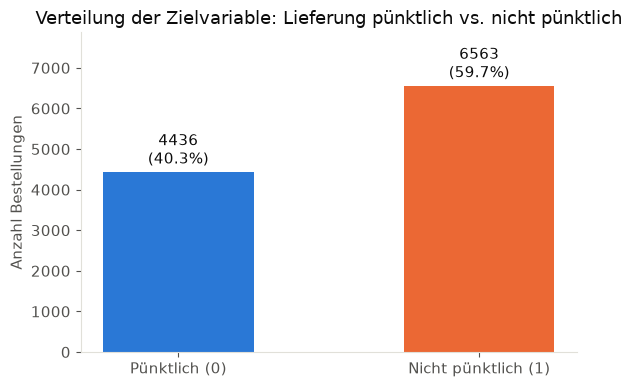

In [12]:
counts = df["Reached.on.Time_Y.N"].value_counts().sort_index()
labels = ["Pünktlich (0)", "Nicht pünktlich (1)"]
colors = [COLOR_BLUE, COLOR_ORANGE]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=colors, width=0.5)

for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
            f"{count}\n({pct:.1f}%)", ha="center", va="bottom")

ax.set_ylabel("Anzahl Bestellungen")
ax.set_title("Verteilung der Zielvariable: Lieferung pünktlich vs. nicht pünktlich")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

**Interpretation:** Von den 10.999 Bestellungen kamen **6.563 zu spät** (59,7 %) und **4.436 pünktlich** (40,3 %) an. Die beiden Gruppen sind also ungefähr gleich gross, mit einem leichten Übergewicht bei den verspäteten Lieferungen.

**Was bedeutet das für unser Modell?**

Ein Programm, das stur bei *jeder* Bestellung "kommt zu spät" rät, läge damit bereits in 59,7 % der Fälle richtig. Das ist unsere Messlatte: Unser Modell muss deutlich besser sein als diese 59,7 %, sonst hat es nichts Nützliches gelernt. Diesen Vergleichswert nennt man **Baseline**.

Ausserdem reicht es später nicht, nur zu zählen, wie viele Vorhersagen insgesamt stimmen (diese Quote heisst **Accuracy**, zu Deutsch Treffergenauigkeit). Wir schauen zusätzlich auf zwei weitere Kennzahlen:
- **Precision** (Genauigkeit): Wenn das Modell "kommt zu spät" sagt — wie oft stimmt das wirklich?
- **Recall** (Trefferquote): Von allen tatsächlich verspäteten Lieferungen — wie viele hat das Modell erkannt?

Beide zusammen zeigen, ob das Modell beide Gruppen gut erkennt oder nur die grössere.

### Visualisierung 2: Korrelationen zwischen den numerischen Merkmalen

Jetzt suchen wir nach Zusammenhängen. Zum Beispiel: Kommen schwere Pakete häufiger zu spät als leichte? Oder hat der Preis etwas damit zu tun?

Dafür berechnen wir für jedes Spaltenpaar die **Korrelation**. Das ist eine einzelne Zahl zwischen -1 und +1, die beschreibt, wie zwei Werte zusammen auftreten:

- **+1** = perfekter Gleichlauf: Wird das eine grösser, wird das andere auch grösser
- **0** = kein erkennbarer Zusammenhang
- **-1** = perfekter Gegenlauf: Wird das eine grösser, wird das andere kleiner

In der Realität landet man fast immer irgendwo dazwischen. Als grobe Orientierung: Werte um 0,1 sind sehr schwach, ab etwa 0,3 spricht man von einem spürbaren Zusammenhang.

Die Grafik unten zeigt alle diese Zahlen gleichzeitig als farbige Tabelle (eine sogenannte **Heatmap**): Rot bedeutet Gleichlauf, Blau Gegenlauf, und je blasser ein Feld, desto schwächer der Zusammenhang. Die rote Diagonale von links oben nach rechts unten ist übrigens ohne Aussagekraft — dort wird jede Spalte mit sich selbst verglichen, was logischerweise immer 1,00 ergibt.

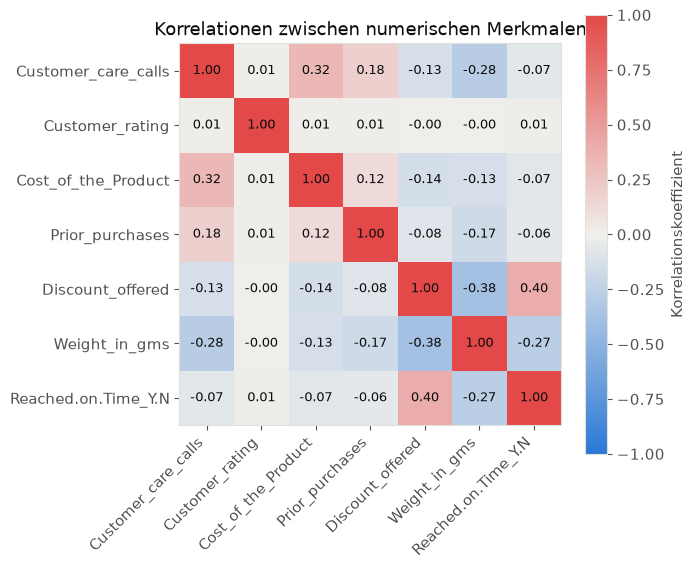

In [13]:
num_cols = ["Customer_care_calls", "Customer_rating", "Cost_of_the_Product",
            "Prior_purchases", "Discount_offered", "Weight_in_gms", "Reached.on.Time_Y.N"]
corr = df[num_cols].corr()

diverging_cmap = LinearSegmentedColormap.from_list(
    "blue_red", ["#2a78d6", "#f0efec", "#e34948"]
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap=diverging_cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color=INK_COLOR, fontsize=9)

fig.colorbar(im, ax=ax, label="Korrelationskoeffizient")
ax.set_title("Korrelationen zwischen numerischen Merkmalen")
plt.tight_layout()
plt.show()

**Interpretation:** Die wichtigste Zeile ist die unterste: Sie zeigt, wie stark jedes Merkmal mit der Verspätung zusammenhängt.

**Der klare Gewinner: `Discount_offered` (+0,40)**
Der Rabatt hat den mit Abstand stärksten Zusammenhang. Das Plus bedeutet: Je höher der Rabatt, desto häufiger kommt die Lieferung zu spät.

**Auf Platz zwei: `Weight_in_gms` (-0,27)**
Hier steht ein Minus davor, der Zusammenhang läuft also andersherum: Je schwerer das Paket, desto **seltener** kommt es zu spät. Schwere Sendungen werden offenbar zuverlässiger geliefert — vielleicht, weil sie anders transportiert oder bevorzugt behandelt werden.

**Der Rest: kaum Zusammenhang**
`Customer_care_calls`, `Cost_of_the_Product` und `Prior_purchases` liegen alle bei etwa -0,07, `Customer_rating` sogar bei 0,01. Diese Merkmale sagen für sich allein genommen so gut wie nichts über eine Verspätung aus. Besonders auffällig ist die Kundenbewertung: Sie hängt praktisch überhaupt nicht damit zusammen, ob die Lieferung pünktlich war — Kundinnen und Kunden bewerten also offenbar nach anderen Kriterien.

**Ein Nebenbefund:** Zwischen `Cost_of_the_Product` und `Customer_care_calls` liegt eine Korrelation von 0,32. Bei teureren Produkten rufen Kundinnen und Kunden also häufiger beim Kundenservice an — was plausibel ist, weil man bei einer teuren Bestellung eher nachfragt, wo die Ware bleibt.

**Fazit für die Modellierung:** `Discount_offered` und `Weight_in_gms` sind die beiden nützlichsten Merkmale, um eine Verspätung vorherzusagen.

### Visualisierung 3: Rabatt nach Lieferstatus

Der Rabatt war in der Korrelationsmatrix der stärkste Zusammenhang. Diesen schauen wir uns jetzt genauer an: Wie viel Rabatt hatten pünktliche Lieferungen, und wie viel die verspäteten?

Dafür verwenden wir einen **Boxplot** ("Kastengrafik"). So liest man ihn:

- Der **Kasten** in der Mitte enthält die mittleren 50 % aller Bestellungen — die "ganz normalen" Fälle
- Der **Strich im Kasten** ist der **Median**: Genau die Hälfte aller Bestellungen liegt darüber, die andere Hälfte darunter
- Die **Striche oben und unten** (die "Antennen") zeigen, wie weit die übrigen Werte reichen

Je höher der Kasten liegt, desto höher waren die Rabatte in dieser Gruppe. Je grösser der Kasten, desto unterschiedlicher waren die Rabatte innerhalb der Gruppe.

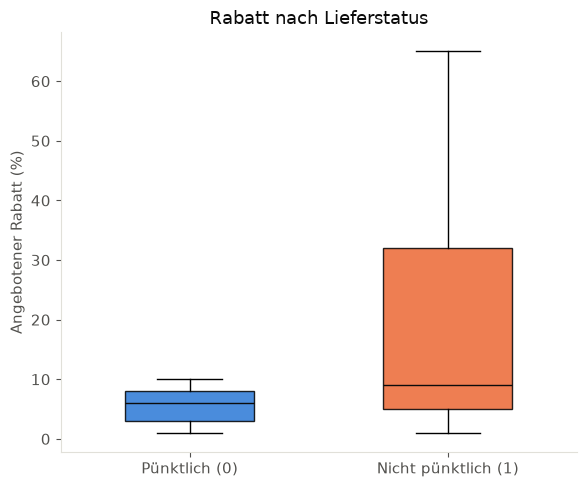

In [14]:
data_by_target = [df.loc[df["Reached.on.Time_Y.N"] == 0, "Discount_offered"],
                  df.loc[df["Reached.on.Time_Y.N"] == 1, "Discount_offered"]]

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(data_by_target, tick_labels=["Pünktlich (0)", "Nicht pünktlich (1)"],
                 patch_artist=True, widths=0.5, medianprops=dict(color=INK_COLOR))

for patch, color in zip(bp["boxes"], [COLOR_BLUE, COLOR_ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_ylabel("Angebotener Rabatt (%)")
ax.set_title("Rabatt nach Lieferstatus")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

**Interpretation:** Der Unterschied ist auf den ersten Blick sichtbar — die beiden Kästen liegen auf völlig verschiedenen Höhen.

- **Pünktliche Lieferungen:** durchschnittlich **5,55 %** Rabatt. Der Kasten ist klein und liegt ganz unten — fast alle diese Bestellungen hatten nur einen kleinen Rabatt (etwa 3 bis 8 %).
- **Verspätete Lieferungen:** durchschnittlich **18,66 %** Rabatt — mehr als das Dreifache. Der Kasten ist viel grösser und reicht bis über 30 %, einzelne Werte sogar bis 65 %.

Anders gesagt: Hohe Rabatte findet man fast ausschliesslich bei Bestellungen, die zu spät kamen. Das ist der deutlichste Zusammenhang im ganzen Datensatz.

**Wichtige Einschränkung — Zusammenhang ist nicht gleich Ursache:**

Es wäre verlockend zu schliessen: "Der Rabatt *verursacht* die Verspätung." Das lässt sich aus diesen Daten aber nicht ableiten.

Genauso könnte es hier eine dritte, nicht erfasste Ursache geben. Denkbar wäre zum Beispiel: Hohe Rabatte gibt es vor allem bei Rabattaktionen, bei denen besonders viele Bestellungen gleichzeitig eingehen — und die überlastete Logistik führt dann zu den Verspätungen. Für die Vorhersage ist das kein Problem (der Zusammenhang funktioniert trotzdem), wohl aber für Handlungsempfehlungen: Rabatte zu streichen würde die Lieferprobleme vermutlich nicht lösen.

### Zusammenfassung der Erkenntnisse aus der EDA

Was wir in diesem Abschnitt über die Daten gelernt haben:

**1. Verspätungen sind der Normalfall, nicht die Ausnahme.**
Knapp 60 % aller Lieferungen kommen zu spät. Für das Unternehmen ist das ein ernsthaftes Problem — für uns bedeutet es, dass unser Modell die 59,7-%-Messlatte schlagen muss, um überhaupt nützlich zu sein.

**2. Der Rabatt ist der deutlichste Hinweis auf eine Verspätung.**
Bestellungen mit hohem Rabatt kommen viel häufiger zu spät (Ø 18,66 % Rabatt gegenüber 5,55 % bei pünktlichen Lieferungen). Das ist mit Abstand das aussagekräftigste Merkmal im Datensatz.

**3. Schwere Pakete kommen zuverlässiger an.**
Je schwerer die Sendung, desto seltener die Verspätung. Der Zusammenhang ist schwächer als beim Rabatt, aber klar erkennbar.

**4. Die meisten anderen Merkmale sagen wenig aus.**
Kundenbewertung, Anzahl Serviceanrufe, Produktpreis und Anzahl früherer Käufe hängen jeweils für sich kaum mit der Pünktlichkeit zusammen. Das heisst nicht, dass sie wertlos sind — ein Modell kann sie in Kombination trotzdem noch sinnvoll nutzen.

**5. Vorsicht bei voreiligen Schlüssen.**
Alle gefundenen Zusammenhänge sagen nur aus, *dass* zwei Dinge gemeinsam auftreten — nicht, dass das eine das andere verursacht. Für Vorhersagen reicht das aus, für konkrete Handlungsempfehlungen an das Unternehmen wären zusätzliche Untersuchungen nötig.

**Was wir daraus mitnehmen:** `Discount_offered` und `Weight_in_gms` dürften die wichtigsten Merkmale für unser Vorhersagemodell werden.

## 2.4 Feature Engineering



### Kategoriale Variablen kodieren

Das Grundproblem: Ein Vorhersagemodell rechnet mit Zahlen. Mit Text wie "SHIP", "HIGH" oder "D" (einem Lagerblock) kann es nichts anfangen — es bricht mit einer Fehlermeldung ab. Wir müssen diese Wörter also in Zahlen übersetzen.

Naheliegend wäre, die Kategorien einfach durchzunummerieren: SHIP=0, FLIGHT=1, ROAD=2. Das wäre aber ein Fehler. Das Modell würde daraus schliessen, ROAD sei "doppelt so viel" wie FLIGHT — eine Bedeutung, die es gar nicht gibt. Die drei Versandarten sind schlicht verschieden, nicht besser oder schlechter.

**Die Lösung: One-Hot-Encoding**

Wir machen aus einer Spalte mehrere Ja/Nein-Spalten. Statt einer Spalte "Versandart" entstehen die Spalten "Ist es ROAD? ja/nein" und "Ist es SHIP? ja/nein". Jede Kategorie bekommt so ihren eigenen Platz, ohne dass eine künstliche Rangfolge entsteht.

**Warum `drop_first=True`?**

Dabei lassen wir bewusst eine Kategorie weg. Der Grund: Wenn "Ist es ROAD?" = nein und "Ist es SHIP?" = nein ist, dann muss es FLIGHT sein — diese dritte Spalte wäre also überflüssig. Sie würde dieselbe Information ein zweites Mal enthalten, was manche Modelle (besonders die Logistic Regression) durcheinanderbringt. Dieses Problem trägt den Namen **Dummy Variable Trap**.

Betroffen sind alle vier Textspalten: `Warehouse_block`, `Mode_of_Shipment`, `Gender` und `Product_importance`.

In [15]:
# One-Hot-Encoding aller kategorialen Spalten
df = pd.get_dummies(
    df,
    columns=["Warehouse_block", "Mode_of_Shipment", "Gender", "Product_importance"],
    drop_first=True,
)

df.head()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_ROAD,Mode_of_Shipment_SHIP,Gender_M,Product_importance_LOW,Product_importance_MEDIUM
0,1,4,2,177,3,44,1233,1,False,False,True,False,False,False,False,True,False
1,2,4,5,216,2,59,3088,1,False,False,False,True,False,False,True,True,False
2,3,2,2,183,4,48,3374,1,False,False,False,False,False,False,True,True,False
3,4,3,3,176,4,10,1177,1,True,False,False,False,False,False,True,False,True
4,5,2,2,184,3,46,2484,1,False,True,False,False,False,False,False,False,True


### Abgeleitetes Feature: Discount_ratio

Neben dem Umwandeln vorhandener Spalten kann man auch **neue Merkmale erfinden**, indem man vorhandene miteinander verrechnet. Ein solches selbst gebautes Merkmal probieren wir hier aus.

**Die Idee dahinter:** Wir setzen den Rabatt ins Verhältnis zum Produktpreis:

`Discount_ratio = Discount_offered / Cost_of_the_Product`

Der Gedanke: Vielleicht ist nicht die Höhe des Rabatts allein entscheidend, sondern wie sie zum Warenwert passt. Ein kräftiger Rabatt auf ein günstiges Produkt könnte ein anderes Geschäft sein als derselbe Rabatt auf ein teures — etwa weil dahinter unterschiedliche Aktionen oder Warengruppen stehen, die auch unterschiedlich versandt werden.

**Ein Vorbehalt vorweg:** `Discount_offered` ist bereits in Prozent angegeben, also ohnehin schon ein Wert *im Verhältnis zum Preis*. Ihn zusätzlich durch den Preis zu teilen, ist rechnerisch zwar möglich, inhaltlich aber fragwürdig. Wir probieren es trotzdem aus — und lassen die Daten entscheiden, statt es uns vorher zurechtzulegen.

In [16]:
df["Discount_ratio"] = df["Discount_offered"] / df["Cost_of_the_Product"]

print(df[["Discount_offered", "Cost_of_the_Product", "Discount_ratio"]].head())
print()
print("Korrelation mit Reached.on.Time_Y.N:")
print(df[["Discount_offered", "Discount_ratio", "Reached.on.Time_Y.N"]].corr()["Reached.on.Time_Y.N"])

   Discount_offered  Cost_of_the_Product  Discount_ratio
0                44                  177        0.248588
1                59                  216        0.273148
2                48                  183        0.262295
3                10                  176        0.056818
4                46                  184        0.250000

Korrelation mit Reached.on.Time_Y.N:
Discount_offered       0.397108
Discount_ratio         0.380484
Reached.on.Time_Y.N    1.000000
Name: Reached.on.Time_Y.N, dtype: float64


**Interpretation:** Unsere Vermutung hat sich **nicht bestätigt**.

| Merkmal | Korrelation mit Verspätung |
|---|---|
| `Discount_offered` (Rabatt in %) | **0,397** |
| `Discount_ratio` (Rabatt nochmals durch den Preis geteilt) | 0,380 |

Das neue Merkmal ist also sogar minimal schlechter als das ursprüngliche.

**Woran liegt das?** Gleich an zwei Dingen:

1. **Der Vorbehalt von oben hat sich bestätigt.** Der Rabatt war als Prozentwert bereits auf den Preis bezogen. Durch das zweite Teilen haben wir keine neue Information gewonnen, sondern eine bestehende verdoppelt angewendet.
2. **Der Preis selbst trägt nichts bei.** `Cost_of_the_Product` hat mit Verspätungen praktisch nichts zu tun (Korrelation nur -0,07). Wir haben also eine gute Information mit einer nutzlosen verrechnet — das Ergebnis ist schwächer als die gute Information allein.

**Warum behalten wir das Merkmal trotzdem?** Die Korrelation misst nur **geradlinige** Zusammenhänge. Modelle wie der Random Forest, die wir später einsetzen, arbeiten anders: Sie treffen Entscheidungen in Stufen ("Ist der Rabatt grösser als 10 %?") und können dabei auch Merkmale nutzen, deren Korrelation nicht besonders hoch ist. Das Merkmal kostet uns nichts, also lassen wir es im Datensatz und schauen später, ob das Modell etwas damit anfangen kann.

**Und das ist ein ganz normales Ergebnis:** Beim Feature Engineering probiert man Ideen aus — manche funktionieren, manche nicht. Wichtig ist, das Ergebnis ehrlich zu prüfen, statt anzunehmen, eine plausibel klingende Idee müsse auch funktionieren.

### Abgeleitetes Feature: Price_per_gram

Ein zweiter Versuch, ein nützliches Merkmal zu bauen — diesmal aus Preis und Gewicht.

**Die Idee dahinter:** Zwei Pakete können gleich schwer sein und trotzdem völlig unterschiedliche Sendungen darstellen. Ein Karton Druckerpapier für 20 Dollar und ein Smartphone für 800 Dollar wiegen vielleicht ähnlich viel — für die Logistik sind es aber zwei verschiedene Welten.

Was sie unterscheidet, ist der **Wert pro Gramm** (die sogenannte "Wertdichte"). Diesen berechnen wir so:

`Price_per_gram = Cost_of_the_Product / Weight_in_gms`

**Warum das interessant sein könnte:** Teure, leichte Ware wird in der Praxis oft anders behandelt als günstige, schwere — etwa per Luftfracht statt per Schiff, mit zusätzlicher Sicherung oder mit bevorzugter Bearbeitung. Falls das auch bei diesem Händler so ist, müsste sich das in den Lieferzeiten zeigen.

Wie beim vorherigen Merkmal prüfen wir direkt nach, ob sich die Vermutung in den Daten bestätigt.

In [17]:
df["Price_per_gram"] = df["Cost_of_the_Product"] / df["Weight_in_gms"]

print(df[["Cost_of_the_Product", "Weight_in_gms", "Price_per_gram"]].head())
print()
print("Korrelation mit Reached.on.Time_Y.N:")
print(df[["Cost_of_the_Product", "Weight_in_gms", "Price_per_gram", "Reached.on.Time_Y.N"]]
      .corr()["Reached.on.Time_Y.N"].round(4))
print()
print("Durchschnittliche Wertdichte nach Lieferstatus:")
print(df.groupby("Reached.on.Time_Y.N")["Price_per_gram"].mean().round(4))

   Cost_of_the_Product  Weight_in_gms  Price_per_gram
0                  177           1233        0.143552
1                  216           3088        0.069948
2                  183           3374        0.054238
3                  176           1177        0.149533
4                  184           2484        0.074074

Korrelation mit Reached.on.Time_Y.N:
Cost_of_the_Product   -0.0736
Weight_in_gms         -0.2688
Price_per_gram         0.0871
Reached.on.Time_Y.N    1.0000
Name: Reached.on.Time_Y.N, dtype: float64

Durchschnittliche Wertdichte nach Lieferstatus:
Reached.on.Time_Y.N
0    0.0733
1    0.0832
Name: Price_per_gram, dtype: float64


**Interpretation:** Auch diese Vermutung bestätigt sich **nicht** — und diesmal sogar noch deutlicher als beim vorherigen Versuch.

| Merkmal | Korrelation mit Verspätung |
|---|---|
| `Weight_in_gms` (Gewicht allein) | **-0,269** |
| `Cost_of_the_Product` (Preis allein) | -0,074 |
| `Price_per_gram` (Preis geteilt durch Gewicht) | 0,087 |

Das neue Merkmal ist mit 0,087 praktisch aussagelos. Besonders auffällig: Das Gewicht allein war mit -0,269 eines der stärksten Merkmale im ganzen Datensatz — durch die Division ist dieses Signal fast vollständig verschwunden.

Ein Blick auf die Durchschnittswerte bestätigt das: Pünktliche Lieferungen haben eine Wertdichte von 0,073 Dollar pro Gramm, verspätete 0,083. Der Unterschied ist da, aber viel zu klein, um daraus etwas ableiten zu können. (Zum Vergleich: Beim Rabatt lagen die Gruppen bei 5,55 % gegenüber 18,66 % — das war ein echter Unterschied.)

**Warum ist das Ergebnis so schlecht?** Wir haben zwei Informationen miteinander verrechnet, von denen nur eine etwas taugt. Das Gewicht sagt etwas aus, der Preis so gut wie nichts. Beim Teilen wird das gute Signal durch das nutzlose verwässert — das Ergebnis ist schlechter als die bessere Zutat allein.

**Was wir daraus lernen:** Beide selbst gebauten Merkmale (`Discount_ratio` und `Price_per_gram`) klangen inhaltlich plausibel, haben in diesem Datensatz aber nichts verbessert. Das ist keine vergeudete Arbeit, sondern normales Vorgehen: Man stellt eine Vermutung auf, prüft sie an den Daten und akzeptiert das Ergebnis. Beide Merkmale bleiben trotzdem im Datensatz — sie schaden nicht, und der Random Forest kann später selbst entscheiden, ob er sie verwendet.

### Abgeleitete Features: High_discount und Weight_critical

Unsere ersten beiden Versuche (`Discount_ratio`, `Price_per_gram`) haben nichts gebracht. Beide hatten dieselbe Schwäche: Wir haben zwei Zahlen durcheinander geteilt und gehofft, dass dabei etwas Besseres herauskommt.

Jetzt versuchen wir etwas anderes. Statt zu rechnen, schauen wir uns erst einmal genau an, **wie** der Zusammenhang eigentlich aussieht — und zwar gruppenweise statt als eine einzige Korrelationszahl.

In [18]:
# Verspätungsrate je Rabatt-Stufe und je Gewichts-Stufe
rabatt_stufen = pd.cut(df["Discount_offered"], [0, 5, 10, 15, 20, 30, 70], include_lowest=True)
gewicht_stufen = pd.cut(df["Weight_in_gms"], [0, 1000, 2000, 3000, 4000, 5000, 6000, 8000])

print("Verspätungsrate nach Rabatt-Stufe:")
print(df.groupby(rabatt_stufen, observed=True)["Reached.on.Time_Y.N"]
        .agg(anzahl="size", anteil_verspaetet="mean").round(3))
print()
print("Verspätungsrate nach Gewichts-Stufe:")
print(df.groupby(gewicht_stufen, observed=True)["Reached.on.Time_Y.N"]
        .agg(anzahl="size", anteil_verspaetet="mean").round(3))

Verspätungsrate nach Rabatt-Stufe:
                  anzahl  anteil_verspaetet
Discount_offered                           
(-0.001, 5.0]       4157              0.474
(5.0, 10.0]         4195              0.464
(10.0, 15.0]         252              1.000
(15.0, 20.0]         244              1.000
(20.0, 30.0]         441              1.000
(30.0, 70.0]        1710              1.000

Verspätungsrate nach Gewichts-Stufe:
               anzahl  anteil_verspaetet
Weight_in_gms                           
(1000, 2000]     3245              0.678
(2000, 3000]      899              1.000
(3000, 4000]      889              0.999
(4000, 5000]     3077              0.437
(5000, 6000]     2881              0.425
(6000, 8000]        8              1.000


**Der Befund ist verblüffend eindeutig — und erklärt einiges.**

**Beim Rabatt gibt es eine harte Kante:**

| Rabatt | Anzahl | davon verspätet |
|---|---|---|
| 0–10 % | 8.352 | 47 % |
| über 10 % | 2.647 | **100 %** |

Ausnahmslos *jede* der 2.647 Bestellungen mit einem Rabatt über 10 % kam zu spät. Es gibt keinen allmählichen Anstieg — es gibt eine Schwelle, und darüber ist die Verspätung sicher.

**Beim Gewicht gibt es ein kritisches Fenster:**

| Gewicht | davon verspätet |
|---|---|
| 1–2 kg | 68 % |
| **2–4 kg** | **~100 %** |
| 4–6 kg | 43 % |

Pakete zwischen 2 und 4 Kilogramm kommen praktisch immer zu spät — leichtere und schwerere dagegen deutlich seltener. Der Zusammenhang läuft also nicht in eine Richtung, sondern hat eine Problemzone in der Mitte.

**Warum hat die Korrelation das nicht gezeigt?**

Weil die Korrelation nur nach *geradlinigen* Zusammenhängen sucht — nach dem Muster "je mehr, desto mehr". Eine Schwelle oder ein Fenster in der Mitte kann sie gar nicht abbilden. Beim Gewicht heben sich die beiden Hälften sogar teilweise gegenseitig auf, weshalb dort nur -0,269 herauskam.

**Unsere Konsequenz:** Wir bauen für beide Muster ein Ja/Nein-Merkmal, das genau diese Schwellen abbildet.

In [19]:
df["High_discount"] = (df["Discount_offered"] > 10).astype(int)
df["Weight_critical"] = df["Weight_in_gms"].between(2000, 4000).astype(int)

print("Korrelation mit Reached.on.Time_Y.N:")
print(df[["Discount_offered", "High_discount", "Weight_in_gms", "Weight_critical",
          "Reached.on.Time_Y.N"]].corr()["Reached.on.Time_Y.N"].round(4))

Korrelation mit Reached.on.Time_Y.N:
Discount_offered       0.3971
High_discount          0.4628
Weight_in_gms         -0.2688
Weight_critical        0.3612
Reached.on.Time_Y.N    1.0000
Name: Reached.on.Time_Y.N, dtype: float64


**Interpretation:** Diesmal hat es funktioniert — beide neuen Merkmale sind stärker als ihre Ausgangsspalten:

| Merkmal | Korrelation mit Verspätung |
|---|---|
| `Discount_offered` (roher Rabatt in %) | 0,397 |
| **`High_discount`** (Rabatt über 10 %, ja/nein) | **0,463** |
| `Weight_in_gms` (rohes Gewicht) | -0,269 |
| **`Weight_critical`** (2–4 kg, ja/nein) | **0,361** |

Besonders deutlich ist der Gewinn beim Gewicht: von -0,269 auf 0,361. Das Merkmal war die ganze Zeit aussagekräftig — wir haben es nur in der falschen Form betrachtet.

**Eine Probe aufs Exempel:** Die simple Regel "Rabatt über 10 % **oder** Gewicht zwischen 2 und 4 kg → kommt zu spät" trifft ganz ohne jedes Modell bereits in **66,8 %** der Fälle zu. Unsere Messlatte lag bei 59,7 % — diese eine Zeile Logik liegt also deutlich darüber und schon nahe an dem, was die trainierten Modelle in Teil 3 erreichen werden.

**Was wir daraus lernen:** Die ersten beiden Ideen scheiterten, weil wir nur gerechnet haben, ohne die Daten anzuschauen. Erst der Blick auf die Gruppen hat die eigentliche Struktur sichtbar gemacht. Feature Engineering heisst also nicht, möglichst viele Spalten zu kombinieren — sondern zu verstehen, welche Form ein Zusammenhang tatsächlich hat.

## 2.5 Train/Test-Split

**Begründung des Verhältnisses (80 % Training / 20 % Test):**

Mit 10.999 Bestellungen haben wir genug Daten, um der üblichen Faustregel 80/20 zu folgen:

- **20 % Testdaten** sind etwa 2.200 Bestellungen — genug, um ein verlässliches Urteil zu fällen. Bei nur 50 Testfällen könnte schon ein einzelner Zufallstreffer das Ergebnis stark verzerren.
- **80 % Trainingsdaten** sind etwa 8.800 Bestellungen — genug Übungsmaterial, damit das Modell die Muster in den Daten erkennen kann.
- Ein extremeres Verhältnis wie 90/10 würde die "Prüfung" unnötig klein und damit unzuverlässig machen. Umgekehrt würde 70/30 dem Modell ohne Not Lernmaterial wegnehmen.

---

**Warum Stratifizierung?**

In Abschnitt 2.3 haben wir gesehen: 59,7 % der Lieferungen kommen zu spät, 40,3 % sind pünktlich. Beim zufälligen Aufteilen könnte es nun passieren, dass dieses Verhältnis in den beiden Teilen verrutscht — etwa dass in den Testdaten plötzlich 70 % verspätete Lieferungen landen.

Das wäre ein Problem: Wir würden das Modell dann an einer Stichprobe prüfen, die gar nicht der Realität entspricht. Das Urteil wäre verzerrt.

**Stratifizierung** (im Code: `stratify=y`) verhindert das. Sie sorgt dafür, dass das Verhältnis 59,7 zu 40,3 in beiden Teilen exakt erhalten bleibt — so wie wenn man ein Kuchenstück abschneidet und darauf achtet, dass in beiden Stücken gleich viele Rosinen sind.

Die Ausgabe unten bestätigt, dass das funktioniert hat: Alle drei Verteilungen (gesamt, Training, Test) sind identisch.

Unrelevante Spalten werden entfernt

In [20]:
X = df.drop(columns=["ID", "Reached.on.Time_Y.N"])
y = df["Reached.on.Time_Y.N"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Trainingsdaten: {X_train.shape[0]} Samples, Testdaten: {X_test.shape[0]} Samples")
print(f"Verwendete Merkmale: {X.shape[1]}")
print()
print("Klassenverteilung gesamt:")
print(y.value_counts(normalize=True).round(3))
print()
print("Klassenverteilung Training:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Klassenverteilung Test:")
print(y_test.value_counts(normalize=True).round(3))

Trainingsdaten: 8799 Samples, Testdaten: 2200 Samples
Verwendete Merkmale: 19

Klassenverteilung gesamt:
Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64

Klassenverteilung Training:
Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64

Klassenverteilung Test:
Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64


# Teil 3 Modellwahl und Training

## 3.1 Modellwahl

Wir wählen zwei Modelle aus, die auf ganz unterschiedliche Weise arbeiten: **Logistic Regression** und **Random Forest**. So sehen wir, ob ein einfacher oder ein komplexer Ansatz besser zu unserem Problem passt.

### Modell 1: Logistic Regression

**Wie funktioniert es?**

Man kann es sich wie ein Punktesystem vorstellen. Jedes Merkmal bekommt eine Punktzahl zugewiesen, die aussagt, wie stark es für oder gegen eine Verspätung spricht — etwa "hoher Rabatt: +3 Punkte", "hohes Gewicht: -2 Punkte". Für jede Bestellung werden alle Punkte zusammengezählt, und das Ergebnis wird in eine Wahrscheinlichkeit zwischen 0 und 100 % umgerechnet.

Liegt diese Wahrscheinlichkeit über 50 %, lautet die Vorhersage "kommt zu spät", sonst "pünktlich".

Beim Training probiert das Modell verschiedene Punktzahlen durch und passt sie so lange an, bis seine Vorhersagen möglichst gut zu den tatsächlichen Lieferungen passen.

**Warum haben wir es gewählt?**

Weil man hineinschauen kann. Die gelernten Punktzahlen lassen sich direkt ablesen, sodass man nachvollziehen kann, *warum* das Modell eine bestimmte Vorhersage trifft. Ausserdem ist es sehr einfach gebaut — es dient uns als Vergleichsmassstab: Wenn ein aufwendigeres Modell nicht besser abschneidet als dieses, lohnt sich der Mehraufwand nicht.

### Modell 2: Random Forest

**Wie funktioniert es?**

Die Grundeinheit ist ein **Entscheidungsbaum** — eine Kette von Ja/Nein-Fragen, ähnlich einem Fragebogen: "Ist der Rabatt höher als 10 %?" → wenn ja: "Wiegt das Paket weniger als 4.000 Gramm?" → wenn ja: "kommt vermutlich zu spät".

Ein einzelner solcher Baum ist allerdings unzuverlässig: Er merkt sich leicht Zufälligkeiten aus den Trainingsdaten. Deshalb baut ein **Random Forest** ("Zufallswald") nicht einen Baum, sondern hunderte — jeder davon mit einem leicht anderen Ausschnitt der Daten. Am Ende stimmen alle Bäume ab, und die Mehrheit entscheidet.

Es ist das gleiche Prinzip wie bei einer Publikumsbefragung: Eine einzelne Person kann danebenliegen, aber der Durchschnitt vieler Einschätzungen ist meist erstaunlich gut.

**Warum haben wir es gewählt?**

In der EDA waren alle Zusammenhänge eher schwach (der stärkste lag bei +0,40). Das deutet darauf hin, dass die Wahrheit komplizierter ist als "je mehr Rabatt, desto später" — vermutlich spielt das **Zusammenspiel** mehrerer Merkmale eine Rolle, etwa hoher Rabatt *in Kombination mit* leichtem Gewicht *und* bestimmter Versandart. Solche Kombinationen kann ein Random Forest erfassen, ein Punktesystem dagegen nur schwer.

Zusätzlich ist er unempfindlich gegenüber den 2.209 Ausreissern, die wir in Abschnitt 2.2 beim Rabatt gefunden haben.

### Was wir vom Vergleich erwarten

Die beiden Modelle stehen für zwei Denkweisen: **einfach und nachvollziehbar** gegen **komplex und flexibel**. Der Vergleich zeigt uns, ob sich die zusätzliche Komplexität hier auszahlt — oder ob das einfache Modell völlig ausreicht.

## 3.2 Training

Jetzt lernen die beiden Modelle anhand der Trainingsdaten.

**Wie prüfen wir während des Trainings, ob es gut läuft?**

Die Testdaten dürfen wir dafür nicht anfassen — die sind für die Schlussprüfung in Teil 4 reserviert. Stattdessen verwenden wir die **Kreuzvalidierung** (englisch *Cross-Validation*).

Das funktioniert so: Wir teilen die Trainingsdaten in 5 gleich grosse Häufchen. Dann trainieren wir das Modell 5-mal — jedes Mal mit 4 Häufchen zum Lernen und dem übrig gebliebenen 5. Häufchen zum Prüfen. So kommt jedes Häufchen genau einmal als Prüfung dran. Am Ende bilden wir den Durchschnitt der 5 Ergebnisse.

**Warum der Aufwand?** Eine einzelne Prüfung kann Glückssache sein. Fünf Prüfungen mit unterschiedlichen Daten ergeben ein deutlich verlässlicheres Bild — und die echten Testdaten bleiben dabei unberührt.

### Modell 1: Logistic Regression

**Ein Problem vorweg: Die Zahlen sind sehr unterschiedlich gross.**

Schauen wir uns die Wertebereiche unserer Merkmale an:
- `Weight_in_gms` geht bis etwa 7.800
- `Discount_ratio` liegt zwischen 0 und ungefähr 0,5

Das sind Grössenordnungen Unterschied. Für die Logistic Regression ist das ein echtes Problem: Sie tastet sich beim Lernen schrittweise an die richtigen Punktzahlen heran, und bei derart verschiedenen Zahlenbereichen kommt sie dabei kaum voran. (Vergleichbar damit, ein Rezept gleichzeitig in Gramm und in Tonnen abzumessen — technisch möglich, aber unnötig fehleranfällig.)

**Die Lösung: Skalieren.**

Der `StandardScaler` rechnet alle Merkmale auf eine gemeinsame Grössenordnung um. Danach sind alle Werte vergleichbar gross, und die inhaltliche Aussage bleibt dabei vollständig erhalten — nur die Masseinheit ändert sich.

**Warum eine Pipeline?**

Die `Pipeline` verbindet die beiden Schritte "Skalieren" und "Trainieren" zu einem einzigen Arbeitsablauf, wie ein Fliessband. Das hat einen wichtigen Vorteil: Der Skalierer lernt seine Umrechnungsregel garantiert nur aus den Trainingsdaten und wendet dann genau dieselbe Regel auf die Testdaten an.

Würde er auch aus den Testdaten lernen, wäre das ein Schummeln (**Data Leakage**) — als hätte man die Prüfungsfragen vorab gesehen. Das Ergebnis würde gut aussehen, wäre aber wertlos. Die Pipeline verhindert diesen Fehler automatisch.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg.fit(X_train, y_train)

cv_log_reg = cross_val_score(log_reg, X_train, y_train, cv=5, scoring="accuracy")
print(f"Logistic Regression - CV-Accuracy: {cv_log_reg.mean():.4f} (+/- {cv_log_reg.std():.4f})")
print(f"Logistic Regression - Train-Accuracy: {log_reg.score(X_train, y_train):.4f}")

Logistic Regression - CV-Accuracy: 0.6742 (+/- 0.0110)
Logistic Regression - Train-Accuracy: 0.6820


**Was wir angepasst haben und warum (Logistic Regression):**

Modelle haben Einstellungen, die man vor dem Training festlegt — sogenannte **Hyperparameter**. Man kann sie sich wie die Regler an einem Gerät vorstellen: Sie bestimmen nicht *was* das Modell lernt, sondern *wie* es lernt.

| Einstellung | Standardwert | Wir nehmen | Warum |
|---|---|---|---|
| Skalierung | keine | `StandardScaler` | Ohne sie findet das Modell selbst nach 1.000 Versuchen keine stabile Lösung und gibt eine Warnung aus (`ConvergenceWarning`). |
| `max_iter` | 100 | 1.000 | Legt fest, wie viele Anpassungsschritte das Modell machen darf. Mit nur 100 bricht es ab, bevor es fertig ist. |
| `random_state` | zufällig | 42 | Sorgt dafür, dass bei jedem Durchlauf exakt dasselbe herauskommt. Sonst wären unsere Ergebnisse nicht reproduzierbar. (Die 42 ist ein beliebiger, in der Praxis üblicher Wert.) |

**Und jetzt die automatische Suche: Grid Search**

Statt weitere Einstellungen von Hand durchzuprobieren, lassen wir den Computer das übernehmen. Beim **Grid Search** ("Rastersuche") geben wir eine Liste möglicher Werte vor, und das Programm probiert **jede Kombination** systematisch durch und misst jeweils per Kreuzvalidierung, wie gut sie funktioniert.

Wir testen zwei Regler:

- **`C`** steuert, wie stark das Modell gebremst wird. Ein kleines `C` zwingt es, sich auf die wichtigsten Merkmale zu beschränken, statt jeder Kleinigkeit in den Daten hinterherzulaufen. Wir probieren 0,01 / 0,1 / 1 / 10.
- **`class_weight`** bestimmt, ob beide Gruppen gleich wichtig genommen werden. Mit `"balanced"` wird die kleinere Gruppe (die pünktlichen Lieferungen, 40,3 %) stärker gewichtet, damit das Modell sie nicht vernachlässigt.

Insgesamt sind das 4 × 2 = 8 Kombinationen, jede fünffach geprüft — also 40 Trainingsdurchläufe, die im Hintergrund ablaufen.

In [22]:
param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"],
}

grid_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring="accuracy", n_jobs=-1)
grid_lr.fit(X_train, y_train)

log_reg_best = grid_lr.best_estimator_

print(f"Beste Parameter: {grid_lr.best_params_}")
print(f"Beste CV-Accuracy: {grid_lr.best_score_:.4f}")

Beste Parameter: {'clf__C': 0.01, 'clf__class_weight': 'balanced'}
Beste CV-Accuracy: 0.6787


### Modell 2: Random Forest

Zuerst trainieren wir den Random Forest so, wie er standardmässig eingestellt ist — ohne jede Anpassung. Das gibt uns einen Ausgangspunkt, an dem wir später messen können, ob unsere Änderungen etwas gebracht haben.

**Ein Unterschied zum vorherigen Modell:** Hier brauchen wir keinen `StandardScaler`. Ein Entscheidungsbaum stellt nur Vergleichsfragen wie "Ist der Rabatt grösser als 10 %?" — und ob dabei in Gramm oder in Tonnen gerechnet wird, spielt für ein Grösser-Kleiner-Urteil keine Rolle. Das Skalieren wäre also einfach überflüssig.

Wir schauen uns dabei **zwei** Zahlen an:
- die **Train-Accuracy**: Wie gut trifft das Modell auf den Daten, mit denen es gelernt hat?
- die **CV-Accuracy** (aus der Kreuzvalidierung): Wie gut trifft es auf Daten, die es beim Lernen nicht gesehen hat?

Der Vergleich der beiden ist gleich noch sehr aufschlussreich.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

cv_rf_default = cross_val_score(rf_default, X_train, y_train, cv=5, scoring="accuracy")
print(f"Random Forest (Default) - CV-Accuracy: {cv_rf_default.mean():.4f} (+/- {cv_rf_default.std():.4f})")
print(f"Random Forest (Default) - Train-Accuracy: {rf_default.score(X_train, y_train):.4f}")

Random Forest (Default) - CV-Accuracy: 0.6606 (+/- 0.0096)
Random Forest (Default) - Train-Accuracy: 1.0000


**Beobachtung: Das Modell hat auswendig gelernt.**

Die beiden Zahlen klaffen dramatisch auseinander:

| Was gemessen wurde | Ergebnis |
|---|---|
| Auf den Trainingsdaten (Train-Accuracy) | **100 %** |
| Auf ungesehenen Daten (CV-Accuracy) | **nur 66,1 %** |

Auf den Übungsaufgaben ist das Modell also fehlerfrei, in der Prüfung fällt es auf 66,1 % ab. Das ist das klassische Anzeichen für **Overfitting** (Überanpassung).

**Was ist da passiert?**

Es ist wie bei jemandem, der zur Prüfungsvorbereitung sämtliche Übungsaufgaben mitsamt Lösungen auswendig lernt, ohne den Stoff zu verstehen. Bei den bekannten Aufgaben: perfekt. Bei neuen Aufgaben: hilflos.

Die technische Ursache liegt in der Einstellung `max_depth`, die standardmässig **unbegrenzt** ist. Die Bäume dürfen also beliebig viele Ja/Nein-Fragen hintereinanderhängen — und mit genug Fragen lässt sich jede einzelne Bestellung eindeutig einkreisen ("Rabatt genau 43 % und Gewicht genau 2.317 Gramm und ..."). Damit merkt sich das Modell Einzelfälle statt allgemeiner Muster.

**Unser Gegenmittel: dem Modell absichtlich weniger Freiheit geben.**

Wir lassen den Grid Search nach Einstellungen suchen, die die Bäume einfacher halten:

- **`max_depth`** (getestet: 5, 10, unbegrenzt) — wie viele Fragen darf ein Baum maximal hintereinander stellen? Das ist der direkteste Hebel gegen Overfitting.
- **`min_samples_leaf`** (getestet: 1, 5, 20) — wie viele Bestellungen müssen mindestens am Ende eines Fragepfads landen? Ein höherer Wert verbietet Regeln, die nur auf eine Handvoll Einzelfälle zutreffen.
- **`n_estimators`** (getestet: 100, 300) — wie viele Bäume sollen abstimmen? Mehr Bäume machen das Ergebnis ruhiger, dauern aber länger.

Das ergibt 3 × 3 × 2 = 18 Kombinationen, jede wieder fünffach geprüft.

In [24]:
param_grid_rf = {
    "n_estimators": [100, 300],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 5, 20],
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf,
                       cv=5, scoring="accuracy", n_jobs=-1)
grid_rf.fit(X_train, y_train)

rf_best = grid_rf.best_estimator_

print(f"Beste Parameter: {grid_rf.best_params_}")
print(f"Beste CV-Accuracy: {grid_rf.best_score_:.4f}")
print(f"Train-Accuracy des besten Modells: {rf_best.score(X_train, y_train):.4f}")
print()
print("Top 5 Parameterkombinationen:")
ergebnisse = pd.DataFrame(grid_rf.cv_results_)[
    ["param_max_depth", "param_min_samples_leaf", "param_n_estimators", "mean_test_score"]
]
print(ergebnisse.sort_values("mean_test_score", ascending=False).head().to_string(index=False))

Beste Parameter: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 300}
Beste CV-Accuracy: 0.6877
Train-Accuracy des besten Modells: 0.6926

Top 5 Parameterkombinationen:
param_max_depth  param_min_samples_leaf  param_n_estimators  mean_test_score
              5                       1                 300         0.687693
              5                       5                 300         0.686897
              5                      20                 300         0.686783
              5                      20                 100         0.686329
              5                       5                 100         0.686102


**Was wir angepasst haben und warum (Random Forest):**

| Einstellung | Standardwert | Wir nehmen | Warum |
|---|---|---|---|
| `max_depth` | unbegrenzt | **5** | Die wichtigste Änderung. Die Bäume dürfen jetzt höchstens 5 Fragen hintereinander stellen und können sich damit keine Einzelfälle mehr merken. Die Train-Accuracy fällt von 100 % auf 69,3 % — und liegt damit fast genau auf dem Prüfungsniveau von 68,8 %. Das Auswendiglernen ist beseitigt. |
| `min_samples_leaf` | 1 | **1** (unverändert) | Hier half eine Erhöhung nicht. Das ist nachvollziehbar: Durch die begrenzte Tiefe entstehen ohnehin keine winzigen Einzelfall-Regeln mehr, um die sich dieser Regler kümmern müsste. |
| `n_estimators` | 100 | **300** | Mehr Bäume, die abstimmen, machen das Ergebnis etwas stabiler. Der Gewinn ist klein, aber die längere Rechenzeit fällt bei dieser Datenmenge nicht ins Gewicht. |

**Die zentrale Erkenntnis: Weniger ist hier mehr.**

Die Rangliste der 18 getesteten Kombinationen zeigt ein verblüffend eindeutiges Muster:

| Baumtiefe | erreichte Genauigkeit |
|---|---|
| **5 (stark begrenzt)** | **68,6 – 68,8 %** |
| 10 (mittel) | 67,7 – 68,2 % |
| unbegrenzt | 65,7 – 67,6 % |

Selbst die schlechteste "einfache" Einstellung schlägt also jede "komplexe". Das Begrenzen der Baumtiefe hat nicht nur das Auswendiglernen behoben — es hat das Modell gleichzeitig **treffsicherer** gemacht. Die Standardeinstellung war für diesen Datensatz schlicht zu mächtig.

Das ist eine der wichtigsten Lektionen im maschinellen Lernen: Ein komplexeres Modell ist nicht automatisch ein besseres.

---

**Zwischenstand beider Modelle** (gemessen per Kreuzvalidierung auf den Trainingsdaten):

| Modell | vor dem Tuning | nach dem Tuning |
|---|---|---|
| Logistic Regression | 67,42 % | 67,87 % |
| Random Forest | 66,06 % | **68,77 %** |

Der angepasste Random Forest liegt vorn — allerdings nur knapp, und die Logistic Regression ist überraschend nah dran. Das passt zu unserem Befund aus Abschnitt 2.4: Die neuen Ja/Nein-Merkmale `High_discount` und `Weight_critical` haben die entscheidenden Schwellen bereits fertig aufbereitet. Damit kann auch das einfache Punktesystem der Regression etwas anfangen, das solche Schwellen von sich aus nicht finden würde.

**Zur Einordnung:** Unsere Messlatte aus der EDA lag bei 59,7 % (immer "kommt zu spät" raten). Beide Modelle liegen deutlich darüber, haben also tatsächlich etwas Verwertbares gelernt. Ob sich das auf den bislang unberührten Testdaten bestätigt, zeigt Teil 4.

## 3.3 Vorhersage

Jetzt kommt der Moment, auf den wir seit Abschnitt 2.5 hingearbeitet haben: Beide fertig trainierten Modelle bekommen die **Testdaten** zu sehen — jene 2.200 Bestellungen, die sie beim Lernen nie zu Gesicht bekommen haben.

Wichtig ist dabei die Reihenfolge: Wir verwenden die Modelle genau so, wie sie aus dem Tuning hervorgegangen sind (`log_reg_best` und `rf_best`). Es wird nichts mehr nachjustiert. Andernfalls wären die Testdaten "verbraucht" und das Ergebnis genauso wertlos wie eine Prüfung, deren Fragen man vorher kannte.

Jedes Modell liefert uns zwei Dinge:

- **Die Vorhersage selbst** (`predict`): 0 = "kommt pünktlich" oder 1 = "kommt zu spät"
- **Die Wahrscheinlichkeit dahinter** (`predict_proba`): Wie sicher sich das Modell ist. Ein Wert von 0,95 heisst "ziemlich sicher zu spät", einer von 0,51 bedeutet praktisch ein Münzwurf.

Die Wahrscheinlichkeit ist in der Praxis oft wertvoller als die reine Ja/Nein-Antwort: Ein Unternehmen könnte damit gezielt nur die Bestellungen priorisieren, bei denen das Modell sich wirklich sicher ist.

In [25]:
# Vorhersagen beider Modelle auf den Testdaten
y_pred_log_reg = log_reg_best.predict(X_test)
y_pred_rf = rf_best.predict(X_test)

# Wahrscheinlichkeit fuer die Klasse 1 ("kommt zu spaet")
proba_log_reg = log_reg_best.predict_proba(X_test)[:, 1]
proba_rf = rf_best.predict_proba(X_test)[:, 1]

print(f"Vorhersagen erstellt fuer {len(y_pred_rf)} Testbestellungen.")

Vorhersagen erstellt fuer 2200 Testbestellungen.


**Die ersten 15 Vorhersagen im Detail**

Um ein Gefühl für die Arbeitsweise der Modelle zu bekommen, schauen wir uns zunächst einzelne Bestellungen an. Die Spalte `Tatsächlich` enthält die Wahrheit, die beiden Modellspalten ihre jeweilige Einschätzung. Die Häkchen am Rand zeigen auf einen Blick, wer richtig lag.

In [26]:
vorhersagen = pd.DataFrame({
    "Tatsächlich": y_test.values,
    "LogReg": y_pred_log_reg,
    "LogReg_Wahrsch.": proba_log_reg.round(2),
    "RandomForest": y_pred_rf,
    "RF_Wahrsch.": proba_rf.round(2),
}, index=y_test.index)

vorhersagen["LogReg_ok"] = ["richtig" if a == b else "FALSCH"
                            for a, b in zip(vorhersagen["Tatsächlich"], vorhersagen["LogReg"])]
vorhersagen["RF_ok"] = ["richtig" if a == b else "FALSCH"
                        for a, b in zip(vorhersagen["Tatsächlich"], vorhersagen["RandomForest"])]

print("0 = puenktlich | 1 = kommt zu spaet")
print()
print(vorhersagen.head(15).to_string())

0 = puenktlich | 1 = kommt zu spaet

      Tatsächlich  LogReg  LogReg_Wahrsch.  RandomForest  RF_Wahrsch. LogReg_ok    RF_ok
1666            1       1             1.00             1         1.00   richtig  richtig
6542            1       0             0.36             0         0.47    FALSCH   FALSCH
6428            0       0             0.32             0         0.44   richtig  richtig
8060            0       0             0.34             0         0.43   richtig  richtig
9822            0       0             0.33             0         0.43   richtig  richtig
4478            1       0             0.38             0         0.42    FALSCH   FALSCH
7037            0       0             0.45             0         0.43   richtig  richtig
6264            1       0             0.37             0         0.47    FALSCH   FALSCH
6461            0       0             0.29             0         0.44   richtig  richtig
2546            1       1             0.99             1         1.00   r

**Die Vorhersagen im Überblick**

Einzelne Zeilen sind anschaulich, aber für ein Gesamturteil brauchen wir die Zusammenfassung über alle 2.200 Testbestellungen.

In [27]:
gesamt = len(y_test)

print("Wie oft wurde welche Klasse vorhergesagt?")
print(f"{'':22s}{'pünktlich (0)':>15s}{'zu spät (1)':>15s}")
for name, pred in [("Tatsächlich", y_test.values),
                   ("Logistic Regression", y_pred_log_reg),
                   ("Random Forest", y_pred_rf)]:
    anzahl_0 = (pred == 0).sum()
    anzahl_1 = (pred == 1).sum()
    print(f"{name:22s}{anzahl_0:>7d} ({anzahl_0/gesamt:>4.0%}){anzahl_1:>8d} ({anzahl_1/gesamt:>4.0%})")

print()
print("Wie viele Vorhersagen waren richtig?")
for name, pred in [("Logistic Regression", y_pred_log_reg), ("Random Forest", y_pred_rf)]:
    treffer = (pred == y_test.values).sum()
    print(f"  {name:22s}{treffer:>6d} von {gesamt}  ({treffer/gesamt:.2%})")

print()
einig = (y_pred_log_reg == y_pred_rf).sum()
print(f"Beide Modelle einig:      {einig:>6d} von {gesamt}  ({einig/gesamt:.2%})")
print(f"Modelle uneinig:          {gesamt-einig:>6d} von {gesamt}  ({(gesamt-einig)/gesamt:.2%})")

Wie oft wurde welche Klasse vorhergesagt?
                        pünktlich (0)    zu spät (1)
Tatsächlich               887 ( 40%)    1313 ( 60%)
Logistic Regression      1604 ( 73%)     596 ( 27%)
Random Forest            1546 ( 70%)     654 ( 30%)

Wie viele Vorhersagen waren richtig?
  Logistic Regression     1479 von 2200  (67.23%)
  Random Forest           1491 von 2200  (67.77%)

Beide Modelle einig:        2140 von 2200  (97.27%)
Modelle uneinig:              60 von 2200  (2.73%)


**Wie sicher sind sich die Modelle?**

Zum Schluss werten wir die Wahrscheinlichkeiten aus. Dazu teilen wir alle Testbestellungen nach der Sicherheit des Random Forest in Gruppen ein und prüfen je Gruppe zweierlei:

- **`anteil_richtig`** — wie oft lag das Modell in dieser Gruppe richtig?
- **`anteil_tatsächlich_spät`** — wie viele dieser Bestellungen kamen wirklich zu spät? Diese Spalte prüft, ob die angegebene Wahrscheinlichkeit auch stimmt: Bei einer Gruppe mit "90 % Verspätungswahrscheinlichkeit" sollten tatsächlich etwa 90 % zu spät kommen.

In [28]:
stufen = pd.cut(proba_rf, [0, 0.45, 0.55, 0.7, 0.9, 1.0], include_lowest=True,
                labels=["unter 45 % (eher pünktlich)", "45-55 % (Münzwurf)",
                        "55-70 % (leichte Tendenz)", "70-90 % (ziemlich sicher)",
                        "über 90 % (so gut wie sicher)"])

auswertung = pd.DataFrame({
    "stufe": stufen,
    "richtig": y_pred_rf == y_test.values,
    "tatsaechlich_spaet": y_test.values,
})

print("Random Forest - Sicherheit der Vorhersage vs. tatsächliches Ergebnis:")
print(auswertung.groupby("stufe", observed=False).agg(
    anzahl=("richtig", "size"),
    anteil_richtig=("richtig", "mean"),
    anteil_tatsaechlich_spaet=("tatsaechlich_spaet", "mean"),
).round(3).to_string())

print()
print(f"Niedrigste vergebene Wahrscheinlichkeit: {proba_rf.min():.2f}")
print(f"Höchste vergebene Wahrscheinlichkeit:    {proba_rf.max():.2f}")

Random Forest - Sicherheit der Vorhersage vs. tatsächliches Ergebnis:
                               anzahl  anteil_richtig  anteil_tatsaechlich_spaet
stufe                                                                           
unter 45 % (eher pünktlich)       935           0.579                      0.421
45-55 % (Münzwurf)                636           0.524                      0.475
55-70 % (leichte Tendenz)          50           0.760                      0.760
70-90 % (ziemlich sicher)          46           1.000                      1.000
über 90 % (so gut wie sicher)     533           1.000                      1.000

Niedrigste vergebene Wahrscheinlichkeit: 0.40
Höchste vergebene Wahrscheinlichkeit:    1.00


**Interpretation der Vorhersagen:**

**1. Beide Modelle sagen Verspätungen deutlich zu selten voraus.**

| | pünktlich (0) | zu spät (1) |
|---|---|---|
| Tatsächlich | 887 (40 %) | 1.313 (60 %) |
| Logistic Regression | 1.604 (73 %) | 596 (27 %) |
| Random Forest | 1.546 (70 %) | 654 (30 %) |

In Wirklichkeit kommen 60 % der Testbestellungen zu spät — vorhergesagt wird das aber nur für knapp 30 %. Die Modelle sind also auffällig zurückhaltend: Wo die Merkmale kein klares Signal liefern, entscheiden sie sich im Zweifel für "pünktlich". Für das Unternehmen bedeutet das, dass viele Verspätungen unentdeckt blieben — ein Punkt, der in Teil 4 genauer zu bewerten sein wird.

**2. Die Modelle sind sich fast immer einig: in 2.140 von 2.200 Fällen (97,3 %).**

Das ist bemerkenswert, denn die beiden arbeiten völlig unterschiedlich — ein Punktesystem gegen einen Wald aus Entscheidungsbäumen. Dass sie trotzdem fast immer zum selben Schluss kommen, spricht dafür, dass beide dieselben echten Muster gefunden haben. Entsprechend nah liegen auch ihre Trefferquoten beieinander: 67,2 % gegenüber 67,8 %.

**3. Der aufschlussreichste Befund: Das Modell ist entweder völlig sicher oder es rät.**

| Sicherheit | Anzahl | davon richtig |
|---|---|---|
| unter 55 % | 1.571 | ~55 % |
| 55–70 % | 50 | 76 % |
| über 70 % | 579 | **100 %** |

Die Testbestellungen zerfallen in zwei Lager. Bei 579 Bestellungen (26 %) ist sich der Random Forest sehr sicher — und liegt dort **ausnahmslos richtig**. Die übrigen 1.571 landen in einem Graubereich um die 45-Prozent-Marke, wo die Trefferquote mit rund 55 % kaum besser ist als Münzewerfen.

Der Grund dafür ist uns bereits aus Abschnitt 2.4 bekannt: Die Regel "Rabatt über 10 % → kommt zu spät" gilt ausnahmslos. Wo sie greift, ist die Sache eindeutig. Wo sie nicht greift, fehlt dem Modell schlicht die Information, um die Verspätung vorherzusagen — die übrigen Merkmale reichen dafür nicht aus.

**Was heisst das praktisch?** Die Wahrscheinlichkeit ist hier wertvoller als die blosse Ja/Nein-Antwort. Das Unternehmen könnte die 26 % eindeutigen Fälle zuverlässig herausfiltern und gezielt gegensteuern, statt sich auf eine Gesamttrefferquote von 68 % zu verlassen, die diese Zweiteilung verdeckt.

# Teil 4 - Auswertung, Fazit und Verbesserungsmöglichkeiten

## 4.1 Modell-Evaluation

Da es sich um eine **binäre Klassifikation** handelt, werden die dafür üblichen Metriken berechnet. Sie beantworten jeweils eine andere Frage:

| Metrik | Beantwortet die Frage |
|---|---|
| **Accuracy** | Wie viele aller Vorhersagen waren richtig? |
| **Precision** | Wenn das Modell "zu spät" meldet — wie oft stimmt das? |
| **Recall** | Von allen wirklich verspäteten Lieferungen — wie viele hat das Modell gefunden? |
| **F1-Score** | Ein kombinierter Wert aus Precision und Recall (deren harmonisches Mittel) |
| **Confusion Matrix** | Welche Arten von Fehlern macht das Modell genau? |

**Welche Metrik ist für unseren Fall die wichtigste?**

Das hängt davon ab, welcher Fehler teurer ist. Unser Anwendungsfall aus Teil 1 lautet: Verspätungen früh erkennen, um Kundinnen und Kunden zu warnen. Dann sind die beiden Fehlertypen unterschiedlich schlimm:

- **Falscher Alarm** (Lieferung als "zu spät" gemeldet, kommt aber pünktlich): ärgerlich, aber harmlos. Der Kunde wurde umsonst informiert.
- **Übersehene Verspätung** (Lieferung als "pünktlich" gemeldet, kommt aber zu spät): genau der Fall, den wir verhindern wollten. Der Kunde wartet, beschwert sich, das Vertrauen leidet.

Der zweite Fehler ist also der teurere — und **Recall** ist die Metrik, die genau ihn misst. Accuracy allein wäre hier irreführend, weil sie beide Fehlerarten gleich gewichtet.

Zum Vergleich nehmen wir ausserdem die **Baseline** mit in die Tabelle auf: die primitivste denkbare Vorhersage, die bei jeder Bestellung stur "kommt zu spät" behauptet. An ihr muss sich jedes Modell messen lassen.

In [29]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

def kennzahlen(y_wahr, y_vorhersage):
    return {
        "Accuracy": accuracy_score(y_wahr, y_vorhersage),
        "Precision": precision_score(y_wahr, y_vorhersage),
        "Recall": recall_score(y_wahr, y_vorhersage),
        "F1-Score": f1_score(y_wahr, y_vorhersage),
    }

# Baseline: immer "kommt zu spaet" vorhersagen
baseline = pd.Series(1, index=y_test.index)

vergleich = pd.DataFrame({
    "Logistic Regression": kennzahlen(y_test, y_pred_log_reg),
    "Random Forest": kennzahlen(y_test, y_pred_rf),
    "Baseline (immer 'zu spät')": kennzahlen(y_test, baseline),
}).round(4)

print("Vergleich der Modelle auf den Testdaten (2.200 Bestellungen)")
print("Bezugsklasse: 1 = 'kommt zu spät'")
print()
print(vergleich.to_string())

Vergleich der Modelle auf den Testdaten (2.200 Bestellungen)
Bezugsklasse: 1 = 'kommt zu spät'

           Logistic Regression  Random Forest  Baseline (immer 'zu spät')
Accuracy                0.6723         0.6777                      0.5968
Precision               0.9966         0.9618                      0.5968
Recall                  0.4524         0.4791                      1.0000
F1-Score                0.6223         0.6396                      0.7475


**Die Fehlerarten im Detail: Confusion Matrix**

Die Tabelle oben fasst zusammen, die Confusion Matrix schlüsselt auf. Sie zeigt für jede der vier möglichen Kombinationen, wie oft sie vorkam:

- **Oben links / unten rechts** = richtig erkannt
- **Oben rechts** = falscher Alarm (pünktlich, aber als "zu spät" gemeldet)
- **Unten links** = übersehene Verspätung (zu spät, aber als "pünktlich" gemeldet) — unser teurer Fehler

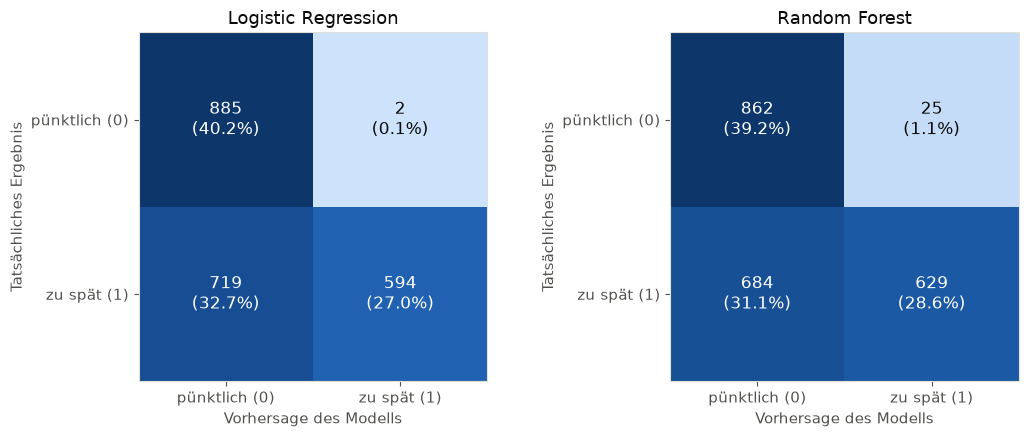

Detaillierter Bericht - Random Forest:
               precision    recall  f1-score   support

pünktlich (0)      0.558     0.972     0.709       887
  zu spät (1)      0.962     0.479     0.640      1313

     accuracy                          0.678      2200
    macro avg      0.760     0.725     0.674      2200
 weighted avg      0.799     0.678     0.667      2200



In [30]:
from matplotlib.colors import LinearSegmentedColormap

blau_ramp = LinearSegmentedColormap.from_list("blau", ["#cde2fb", "#2a78d6", "#0d366b"])
beschriftung = ["pünktlich (0)", "zu spät (1)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (titel, vorhersage) in zip(axes, [("Logistic Regression", y_pred_log_reg),
                                          ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, vorhersage)
    ax.imshow(cm, cmap=blau_ramp, vmin=0, vmax=cm.max())

    for zeile in range(2):
        for spalte in range(2):
            wert = cm[zeile, spalte]
            ax.text(spalte, zeile, f"{wert}\n({wert/cm.sum():.1%})", ha="center", va="center",
                    fontsize=12, color="#ffffff" if wert > cm.max() * 0.5 else INK_COLOR)

    ax.set_xticks([0, 1], beschriftung)
    ax.set_yticks([0, 1], beschriftung)
    ax.set_xlabel("Vorhersage des Modells")
    ax.set_ylabel("Tatsächliches Ergebnis")
    ax.set_title(titel)

plt.tight_layout()
plt.show()

print("Detaillierter Bericht - Random Forest:")
print(classification_report(y_test, y_pred_rf,
                            target_names=["pünktlich (0)", "zu spät (1)"], digits=3))

## 4.2 Interpretation

### Was sagen die Metriken aus?

| Metrik | LogReg | Random Forest | Baseline | Was das bedeutet |
|---|---|---|---|---|
| Accuracy | 0,672 | **0,678** | 0,597 | 8 Prozentpunkte über der Baseline — ein echter, aber bescheidener Gewinn |
| Precision | **0,997** | 0,962 | 0,597 | Ein Alarm des Modells ist fast immer berechtigt |
| Recall | 0,452 | 0,479 | **1,000** | **Das Problem:** Weniger als die Hälfte aller Verspätungen wird erkannt |
| F1-Score | 0,622 | 0,640 | **0,747** | Der schwache Recall zieht den Wert unter die Baseline |

**Die zentrale Aussage steckt im Gegensatz zwischen Precision und Recall.**

Die Modelle sind extrem vorsichtig: Sie melden nur dann "zu spät", wenn sie sich sicher sind. Daher die fast perfekte Precision — aber daher auch der schwache Recall. Der Random Forest übersieht **684 von 1.313** tatsächlich verspäteten Lieferungen.

Anschaulich gesprochen verhält sich das Modell wie ein Wachmann, der nur bei einem Einbruch Alarm schlägt, den er selbst mit eigenen Augen sieht. Schlägt er Alarm, liegt er richtig — aber er verschläft mehr als die Hälfte aller Einbrüche.

### Ein unbequemer Befund: Die Baseline schlägt beide Modelle

Die Baseline-Spalte verdient besondere Aufmerksamkeit. Sie steht für die primitivste denkbare "Vorhersage": bei *jeder* Bestellung stur "kommt zu spät" behaupten, ohne einen einzigen Blick in die Daten.

- Beim **Recall** erreicht sie zwangsläufig 1,000 — wer immer Alarm schlägt, verpasst keine einzige Verspätung.
- Beim **F1-Score** liegt sie mit 0,747 deutlich über beiden Modellen (0,622 und 0,640).

Nur bei der **Accuracy** liegen unsere Modelle vorn (0,678 gegenüber 0,597).

**Wie ist das einzuordnen?** Die Baseline ist praktisch wertlos, denn sie unterscheidet nicht — sie warnt bei allem und hilft deshalb bei keiner Entscheidung. Trotzdem ist der Vergleich ernüchternd: Ausgerechnet bei der Metrik, die für unseren Anwendungsfall am wichtigsten ist (Recall), schneidet unser trainiertes Modell schlechter ab als blindes Raten in eine Richtung.

Dieser Befund ist kein Fehler in der Umsetzung, sondern eine ehrliche Auskunft über die Datenlage — und er weist direkt auf eine Verbesserungsmöglichkeit hin: Die Entscheidungsschwelle liegt derzeit bei 50 % und macht das Modell übervorsichtig. Wo genau der richtige Punkt zwischen "warnt zu selten" und "warnt bei allem" liegt, ist eine geschäftliche Abwägung, keine statistische (siehe Abschnitt 4.4).

### Ist das Modell gut genug für den Praxiseinsatz?

**Für den ursprünglich gedachten Zweck: nein.** Das Ziel war, Verspätungen frühzeitig zu erkennen, um gegensteuern zu können. Mit einem Recall von 48 % bliebe über die Hälfte aller Problemfälle unentdeckt — die betroffenen Kundinnen und Kunden würden genauso überrascht wie ohne Modell.

**Für einen eingeschränkten Zweck: ja.** Wie in Abschnitt 3.3 gezeigt, ist das Modell bei 579 Bestellungen (26 % des Testsets) sehr sicher — und liegt dort ausnahmslos richtig. Dieses Viertel lässt sich zuverlässig herausfiltern und gezielt behandeln.

**Der entscheidende Vorbehalt:** Die simple Regel "Rabatt über 10 % → kommt zu spät" erreicht für sich genommen bereits 64,0 % Genauigkeit. Das vollständige Modell mit 19 Merkmalen, Tuning und Grid Search kommt auf 67,8 % — ein Zugewinn von nur **3,8 Prozentpunkten**. Der Aufwand eines ML-Modells rechtfertigt sich damit hier kaum; eine einzelne Wenn-Dann-Regel leistet fast dasselbe.

### Welches Modell schneidet besser ab?

Der **Random Forest** gewinnt — aber nur knapp: bei Accuracy (+0,5 Prozentpunkte), Recall (+2,7) und F1 (+1,7) liegt er vorn, bei Precision minimal hinten.

**Warum liegt er vorn?** Er kann Merkmale kombinieren und Schwellenwerte selbst finden ("Rabatt über X **und** Gewicht unter Y"). Die Logistic Regression kann nur jedes Merkmal einzeln gewichten und addieren.

**Warum ist der Abstand so klein?** Weil wir ihm die Arbeit in Abschnitt 2.4 bereits abgenommen haben. Die Merkmale `High_discount` und `Weight_critical` enthalten die entscheidenden Schwellen schon fertig — und damit kann auch die Logistic Regression umgehen. Ohne diese beiden Merkmale war der Abstand deutlich grösser (68,2 % gegenüber 65,1 %).

**Eine praktische Abwägung:** Die Logistic Regression hat mit 99,7 % die höhere Precision — von 596 Warnungen waren nur **2** falsch. Wenn jeder falsche Alarm teuer wäre (etwa weil er eine kostenpflichtige Eilzustellung auslöst), wäre sie trotz schlechterem Gesamtergebnis die bessere Wahl.

### Welche Features sind am wichtigsten?

Der Random Forest kann angeben, wie stark er sich auf jedes einzelne Merkmal gestützt hat. Zum Vergleich betrachten wir daneben die Gewichte der Logistic Regression — die zeigen zusätzlich die **Richtung** des Einflusses.

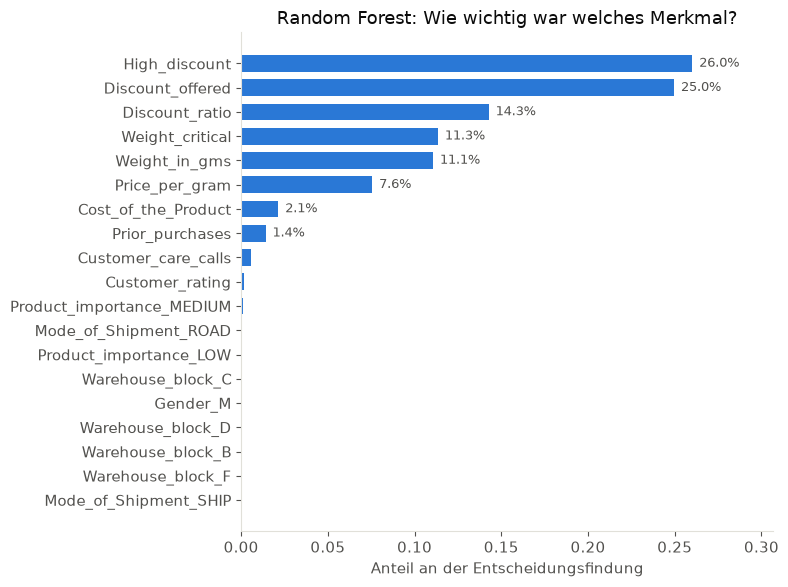

Gewichte der Logistic Regression (Vorzeichen = Richtung des Einflusses):
High_discount       0.894
Weight_critical     0.812
Weight_in_gms      -0.356
Discount_ratio      0.317
Discount_offered    0.262
Price_per_gram     -0.150


In [31]:
wichtigkeit = pd.Series(rf_best.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
balken = ax.barh(wichtigkeit.index, wichtigkeit.values, color=COLOR_BLUE, height=0.7)

for balken_einzeln, wert in zip(balken, wichtigkeit.values):
    if wert > 0.01:
        ax.text(wert + 0.004, balken_einzeln.get_y() + balken_einzeln.get_height() / 2,
                f"{wert:.1%}", va="center", fontsize=9, color=TEXT_COLOR)

ax.set_xlabel("Anteil an der Entscheidungsfindung")
ax.set_title("Random Forest: Wie wichtig war welches Merkmal?")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, wichtigkeit.max() * 1.18)
plt.tight_layout()
plt.show()

print("Gewichte der Logistic Regression (Vorzeichen = Richtung des Einflusses):")
koeffizienten = pd.Series(log_reg_best.named_steps["clf"].coef_[0], index=X_train.columns)
print(koeffizienten.reindex(koeffizienten.abs().sort_values(ascending=False).index).head(6).round(3).to_string())

**Interpretation der Feature Importance:**

| Merkmal | Anteil |
|---|---|
| `High_discount` | 26,0 % |
| `Discount_offered` | 25,0 % |
| `Discount_ratio` | 14,3 % |
| `Weight_critical` | 11,4 % |
| `Weight_in_gms` | 11,1 % |
| `Price_per_gram` | 7,6 % |
| alle übrigen 13 Merkmale zusammen | ~4,6 % |

**1. Rund zwei Drittel der Entscheidung hängen am Rabatt.** Die drei Rabatt-Merkmale zusammen machen 65,4 % aus. Das bestätigt, was sich seit der EDA abzeichnete.

**2. Das Gewicht liefert den Rest.** `Weight_critical` und `Weight_in_gms` kommen zusammen auf 22,5 %.

**3. Alle anderen Merkmale sind praktisch bedeutungslos.** Lagerblock, Versandart, Geschlecht, Kundenbewertung, Produktwichtigkeit und Anzahl früherer Käufe tragen zusammen weniger als 5 % bei. Besonders bemerkenswert: Die **Versandart** (Flugzeug, Schiff, Strasse) spielt für die Pünktlichkeit offenbar keine Rolle — was für einen Logistikdatensatz überraschend ist und den Verdacht stützt, dass der Datensatz teilweise künstlich erzeugt wurde.

**4. Unsere "gescheiterten" Merkmale werden doch genutzt.** `Discount_ratio` (14,3 %) und `Price_per_gram` (7,6 %) landen auf Platz 3 und 6 — obwohl beide in Abschnitt 2.4 eine schwächere Korrelation hatten als ihre Ausgangsspalten. Das bestätigt die damalige Entscheidung, sie trotzdem zu behalten: Ein Baum-Modell kann Merkmale sinnvoll einsetzen, bei denen die lineare Korrelation wenig hergibt.

**5. Die Logistic Regression bestätigt die Richtung.** Ihre grössten Gewichte sind `High_discount` (+0,89) und `Weight_critical` (+0,81) — beide positiv, erhöhen also die Verspätungswahrscheinlichkeit. `Weight_in_gms` ist mit -0,36 negativ: Je schwerer, desto pünktlicher.

## 4.3 Fazit

### Die Business-Fragestellung aus Teil 1

> *Kann das Unternehmen anhand von Bestell-, Versand- und Kundenmerkmalen einer neuen Sendung frühzeitig erkennen, ob diese sich verspäten wird, um durch gezieltes Gegensteuern Reklamationen zu vermeiden und die Kundenzufriedenheit zu erhöhen?*

**Die Antwort lautet: teilweise — für etwa ein Viertel der Bestellungen ja, für den Rest nein.**

**Was funktioniert:** Bei 26 % aller Bestellungen kann das Unternehmen die Verspätung mit praktisch vollständiger Sicherheit vorhersagen. Es handelt sich dabei um die Bestellungen mit einem Rabatt über 10 %, die im Datensatz **ausnahmslos** zu spät ankamen — 2.647 von 2.647 Fällen. Für diese Gruppe ist gezieltes Gegensteuern ohne Weiteres möglich.

**Was nicht funktioniert:** Bei den übrigen 74 % liefert das Modell kaum mehr als einen Münzwurf (Trefferquote rund 55 %). Über alle Bestellungen hinweg werden nur 48 % der Verspätungen erkannt. Für ein zuverlässiges Frühwarnsystem, das den Namen verdient, reicht das nicht.

### Wurde das Ziel erreicht?

**Methodisch ja, praktisch nur eingeschränkt.**

Der Analyseprozess hat funktioniert und belastbare Erkenntnisse geliefert:

- Die Datenqualität wurde geprüft (keine fehlenden Werte, keine Duplikate, Ausreisser untersucht)
- Die EDA hat die entscheidenden Zusammenhänge freigelegt
- Das Feature Engineering hat die tatsächliche Form dieser Zusammenhänge erfasst (Schwellenwerte statt gerader Linien) und beide Modelle messbar verbessert
- Zwei Modelle wurden sauber trainiert, getunt und auf ungesehenen Daten bewertet
- Overfitting wurde erkannt und behoben (Train-Accuracy von 100 % auf 69 %)

**Die wichtigste Erkenntnis ist aber eine andere:** Das Modell scheitert nicht am Verfahren, sondern am Datensatz. Die Faktoren, die Lieferverspätungen tatsächlich verursachen — Entfernung, Wetter, Zoll, Auslastung des Logistikpartners, Saison — sind schlicht nicht erfasst. Genau diese Lücke war in Teil 1 unter "Einschränkungen" bereits als Risiko benannt worden; sie hat sich nun bestätigt.

**Ein kritischer Hinweis zur Datenquelle:** Dass eine Regel wie "Rabatt über 10 % → zu spät" in 2.647 von 2.647 Fällen ausnahmslos zutrifft, kommt in echten Betriebsdaten praktisch nicht vor. Auch dass die Versandart (Flugzeug/Schiff/Strasse) keinerlei Einfluss auf die Pünktlichkeit hat, ist logistisch schwer erklärbar. Beides deutet darauf hin, dass dieser Datensatz zumindest teilweise synthetisch erzeugt wurde. Ergebnisse daraus sollten daher nicht ungeprüft auf reale Geschäftsentscheidungen übertragen werden.

## 4.4 Verbesserungsmöglichkeiten

### 1. Bessere Daten — der mit Abstand grösste Hebel

Die Analyse hat gezeigt, dass die vorhandenen Merkmale für 74 % der Bestellungen keine Aussage zulassen. Kein noch so gutes Modell kann Informationen nutzen, die nicht erfasst sind. Konkret fehlen:

- **Zeitangaben**: Bestelldatum, Wochentag, Uhrzeit, Saison (Weihnachtsgeschäft!), zugesagtes Lieferdatum
- **Geografie**: Lieferentfernung, Zielland, Zollrelevanz
- **Logistik**: konkreter Versanddienstleister, dessen aktuelle Auslastung, Bearbeitungsdauer im Lager
- **Äussere Einflüsse**: Wetter, Streiks, Feiertage am Zielort

Schon das Bestelldatum allein würde vermutlich mehr bringen als alle bisherigen Merkmale zusammen, weil sich damit Saisonspitzen und Wochentagsmuster abbilden liessen.

### 2. Die Entscheidungsschwelle anpassen

Aktuell entscheiden beide Modelle bei 50 % Wahrscheinlichkeit. Das führt zu der extremen Schieflage von 96 % Precision bei nur 48 % Recall — das Modell warnt zu selten.

Senkt man die Schwelle auf beispielsweise 45 %, meldet das Modell häufiger "zu spät". Der Recall steigt, die Precision sinkt. Da eine übersehene Verspätung für das Unternehmen teurer ist als ein falscher Alarm, wäre dieser Tausch wahrscheinlich lohnend. Diese Anpassung kostet nichts — es ist eine reine Stellschraube am fertigen Modell und erfordert kein neues Training. Ein Precision-Recall-Diagramm würde zeigen, wo der beste Kompromiss liegt.

### 3. Weitere Modelle ausprobieren

Naheliegend wäre **Gradient Boosting** (XGBoost oder LightGBM). Diese Verfahren bauen ihre Bäume nacheinander auf, wobei jeder neue Baum gezielt die Fehler seiner Vorgänger korrigiert — bei tabellarischen Daten schneiden sie oft besser ab als ein Random Forest.

Angesichts der klaren Befunde ist der zu erwartende Gewinn hier allerdings gering: Die Daten geben schlicht nicht mehr her. Realistisch wären ein bis zwei Prozentpunkte.

### 4. Feature Engineering vertiefen

Die Schwellenwerte 10 % (Rabatt) und 2.000–4.000 g (Gewicht) wurden von Hand aus Häufigkeitstabellen abgelesen. Systematischer wäre:

- Die optimalen Schwellen automatisch bestimmen lassen (etwa über einen einzelnen Entscheidungsbaum)
- Kombinationsmerkmale testen, zum Beispiel `High_discount UND Weight_critical`
- Die Warnung aus Abschnitt 2.4 beherzigen: erst die Struktur der Daten ansehen, dann Merkmale bauen — nicht umgekehrt

### 5. Die Datenquelle klären

Bevor weiterer Aufwand in die Modellierung fliesst, sollte geprüft werden, ob die auffälligen Muster (ausnahmslose Rabattregel, wirkungslose Versandart) echt sind oder Artefakte der Datenerzeugung. Falls Letzteres zutrifft, wäre jede Optimierung an diesem Datensatz vergebene Mühe — dann bräuchte es echte Betriebsdaten statt eines besseren Modells.